# DSA 210 DATA SCIENCE PROJECT 
## The Impact of Crude Oil Prices on Food Sector Stock Prices


---
Alperen SARIŞEN 33886


## Part 1. Imports & Setup

In this initial step, we import the necessary Python libraries for data manipulation (pandas), visualization (matplotlib, seaborn), and statistical analysis (scipy). We then fetch historical stock data for the food sector (KO, KHC, MCD, MDLZ) via yfinance and load the daily Brent Crude Oil price dataset. Both datasets are merged on a daily date key, and missing values—primarily due to stock market holidays and weekends—are handled using the forward-filling method to ensure a continuous time series for analysis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import pearsonr, spearmanr, shapiro, ttest_ind



## 2. Data Collection & Loading

We use:
- **Brent Oil Prices** – downloaded from Kaggle (`BrentOilPrices.csv`)
- **Food Sector Stocks** – downloaded via `yfinance`: KO, KHC, MCD, MDLZ


In [14]:
# Load brent oil from CSV (downloaded from Kaggle)
brent = pd.read_csv("BrentOilPrices.csv")
brent = brent.rename(columns={"Date": "date", "Price": "brent_price"})
brent["date"] = pd.to_datetime(brent["date"], dayfirst=True)
brent = brent.sort_values("date")
brent = brent[(brent["date"] >= "2015-01-01") & (brent["date"] <= "2023-12-31")]
brent = brent.reset_index(drop=True)

print("Brent oil loaded:", len(brent), "rows")
print(brent["date"].min(), "->", brent["date"].max())

Brent oil loaded: 2005 rows
2015-01-02 00:00:00 -> 2022-11-14 00:00:00


In [15]:
# Download stock data using yfinance
KO   = yf.download("KO",   start="2015-01-01", end="2023-12-31", auto_adjust=True)["Close"]
KHC  = yf.download("KHC",  start="2015-01-01", end="2023-12-31", auto_adjust=True)["Close"]
MCD  = yf.download("MCD",  start="2015-01-01", end="2023-12-31", auto_adjust=True)["Close"]
MDLZ = yf.download("MDLZ", start="2015-01-01", end="2023-12-31", auto_adjust=True)["Close"]

print("KO shape:",   KO.shape)
print("KHC shape:",  KHC.shape)
print("MCD shape:",  MCD.shape)
print("MDLZ shape:", MDLZ.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

KO shape: (2264, 1)
KHC shape: (2138, 1)
MCD shape: (2264, 1)
MDLZ shape: (2264, 1)


## 3. Merge Datasets

In [18]:
# Put stocks into one dataframe
stocks = pd.DataFrame({
    "date": KO.index,
    "KO":   KO.values.flatten(),
    "KHC":  KHC.reindex(KO.index).values.flatten(),
    "MCD":  MCD.reindex(KO.index).values.flatten(),
    "MDLZ": MDLZ.reindex(KO.index).values.flatten()
})
stocks["date"] = pd.to_datetime(stocks["date"])

# Merge with brent
df = pd.merge(brent, stocks, on="date", how="outer")
df = df.sort_values("date")
df = df.ffill()
df = df.dropna()
df = df.reset_index(drop=True)

print(df.shape)
df.head()


(2180, 6)


,date,brent_price,KO,KHC,MCD,MDLZ
0,2015-07-06,57.19,28.130497,45.202484,73.337120,32.302959
1,2015-07-07,54.72,28.722803,46.237125,74.126854,32.710083
2,2015-07-08,55.70,28.444490,46.714191,73.482803,32.420414
3,2015-07-09,57.83,28.487303,46.342472,73.981194,32.295128
4,2015-07-10,57.72,28.822701,47.897533,74.870598,32.420414


## 4. EDA

### 4.1 Basic Stats


In [19]:
df.describe()

,date,brent_price,KO,KHC,MCD,MDLZ
count,2180,2180.000000,2180.000000,2180.000000,2180.000000,2180.000000
mean,2019-09-29 00:00:39.633027,66.414963,41.915061,37.032809,169.829874,45.495254
min,2015-07-06 00:00:00,9.120000,27.110041,15.081261,69.932861,28.672642
25%,2017-08-16 18:00:00,49.097500,34.030733,28.183279,127.550085,35.161758
50%,2019-09-30 12:00:00,64.000000,39.995096,32.806135,167.955032,44.729374
75%,2021-11-09 06:00:00,81.887500,49.257967,47.898580,218.672501,54.832808
max,2023-12-29 00:00:00,133.180000,58.804935,63.035568,281.324554,72.064331
std,NaN,21.795497,9.037823,12.289729,57.398844,11.031085


### 4.2 Brent Oil Price Over Time

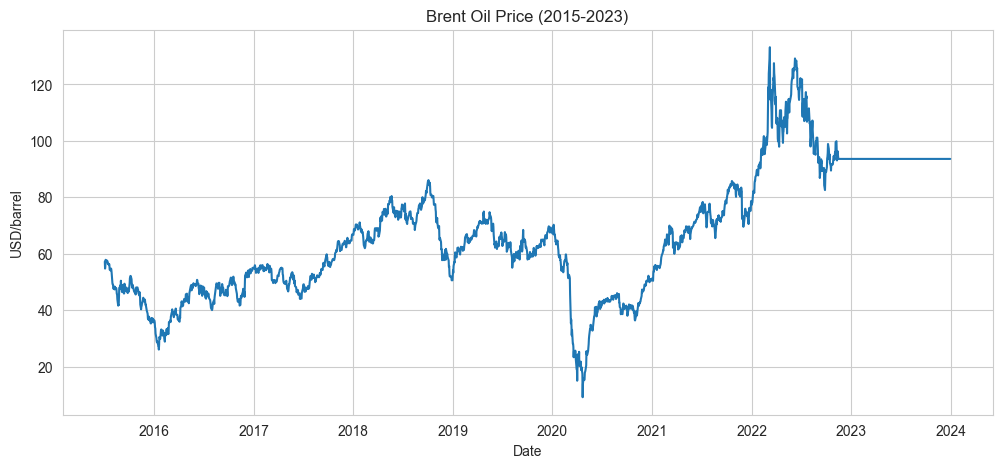

In [20]:
plt.figure()
plt.plot(df["date"], df["brent_price"])
plt.title("Brent Oil Price (2015-2023)")
plt.xlabel("Date")
plt.ylabel("USD/barrel")
plt.show()


### 4.3 Stock Prices Over Time

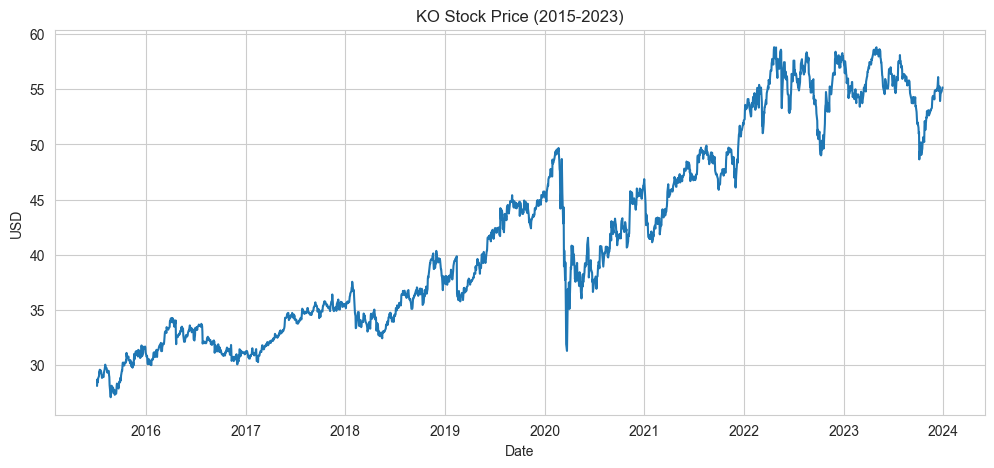

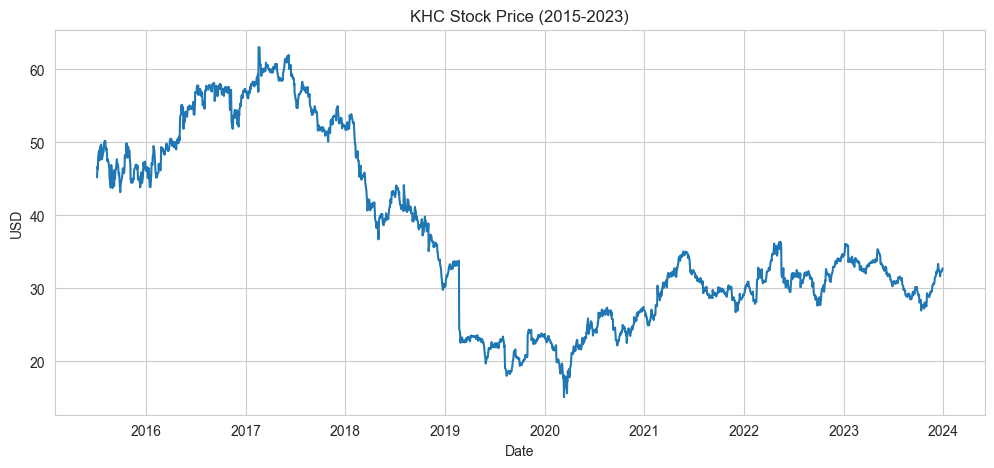

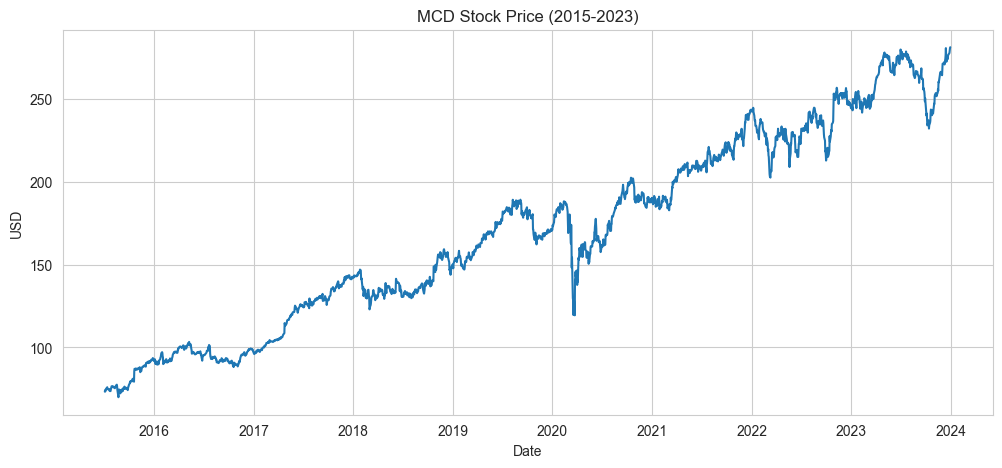

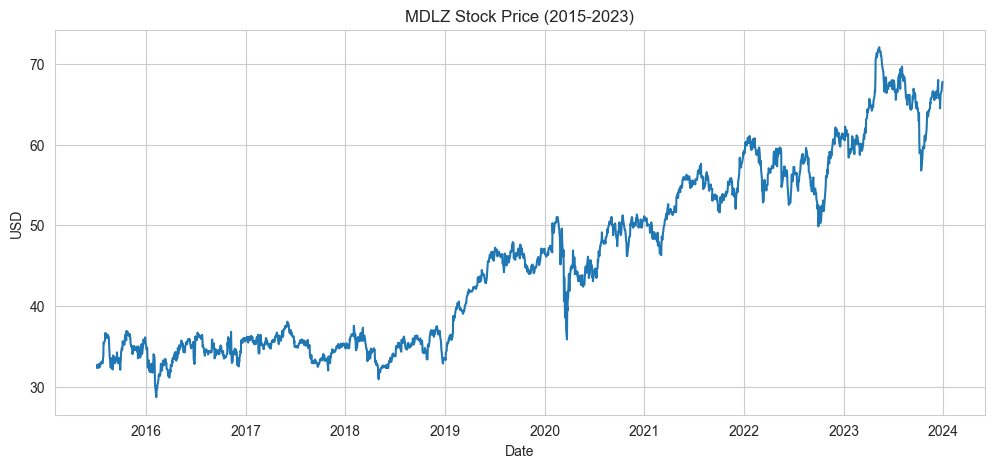

In [21]:
plt.figure()
plt.plot(df["date"], df["KO"])
plt.title("KO Stock Price (2015-2023)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()

plt.figure()
plt.plot(df["date"], df["KHC"])
plt.title("KHC Stock Price (2015-2023)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()

plt.figure()
plt.plot(df["date"], df["MCD"])
plt.title("MCD Stock Price (2015-2023)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()

plt.figure()
plt.plot(df["date"], df["MDLZ"])
plt.title("MDLZ Stock Price (2015-2023)")
plt.xlabel("Date")
plt.ylabel("USD")
plt.show()


### 4.4 Log Returns

In [22]:
df["brent_ret"] = np.log(df["brent_price"] / df["brent_price"].shift(1))
df["KO_ret"]    = np.log(df["KO"]   / df["KO"].shift(1))
df["KHC_ret"]   = np.log(df["KHC"]  / df["KHC"].shift(1))
df["MCD_ret"]   = np.log(df["MCD"]  / df["MCD"].shift(1))
df["MDLZ_ret"]  = np.log(df["MDLZ"] / df["MDLZ"].shift(1))

df = df.dropna()
df.head()


,date,brent_price,KO,KHC,MCD,MDLZ,brent_ret,KO_ret,KHC_ret,MCD_ret,MDLZ_ret
1,2015-07-07,54.72,28.722803,46.237125,74.126854,32.710083,-0.044150,0.020837,0.022631,0.010711,0.012525
2,2015-07-08,55.70,28.444490,46.714191,73.482803,32.420414,0.017751,-0.009737,0.010265,-0.008726,-0.008895
3,2015-07-09,57.83,28.487303,46.342472,73.981194,32.295128,0.037528,0.001504,-0.007989,0.006760,-0.003872
4,2015-07-10,57.72,28.822701,47.897533,74.870598,32.420414,-0.001904,0.011705,0.033005,0.011950,0.003872
5,2015-07-13,57.63,29.015379,48.839249,75.468628,32.569153,-0.001560,0.006663,0.019470,0.007956,0.004577


### 4.5 Return Distributions

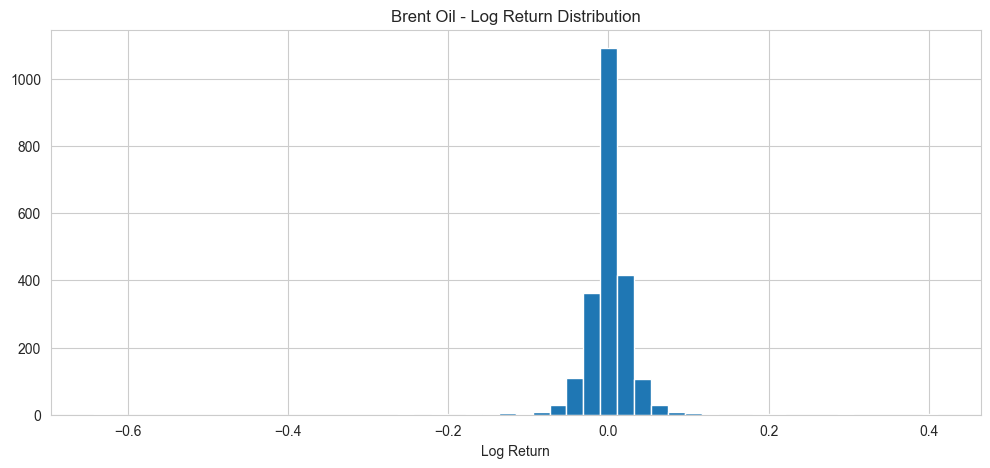

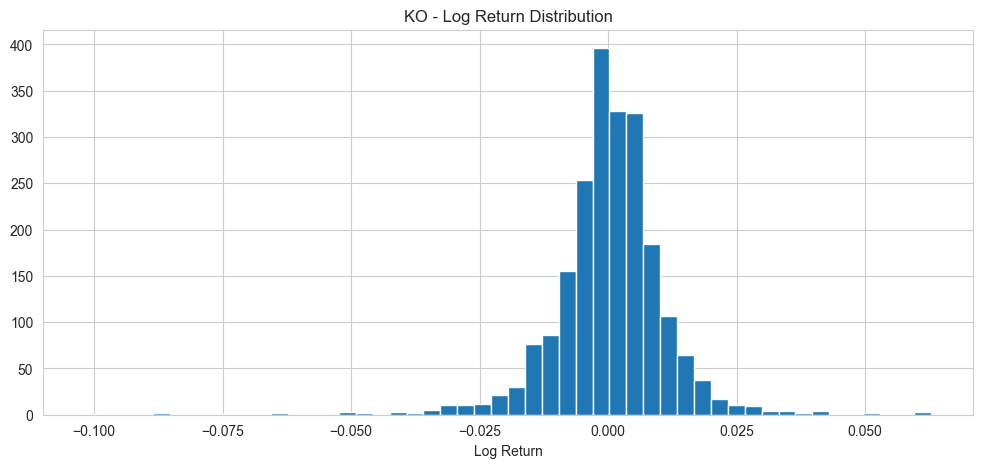

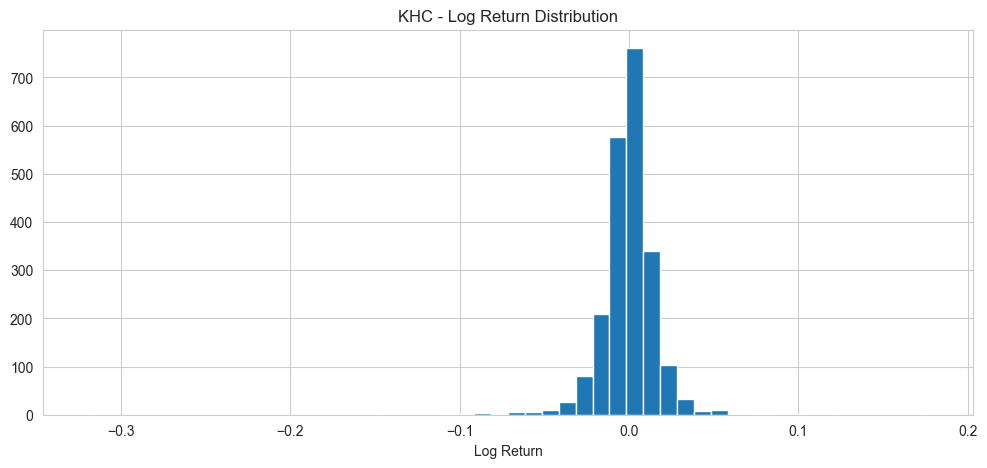

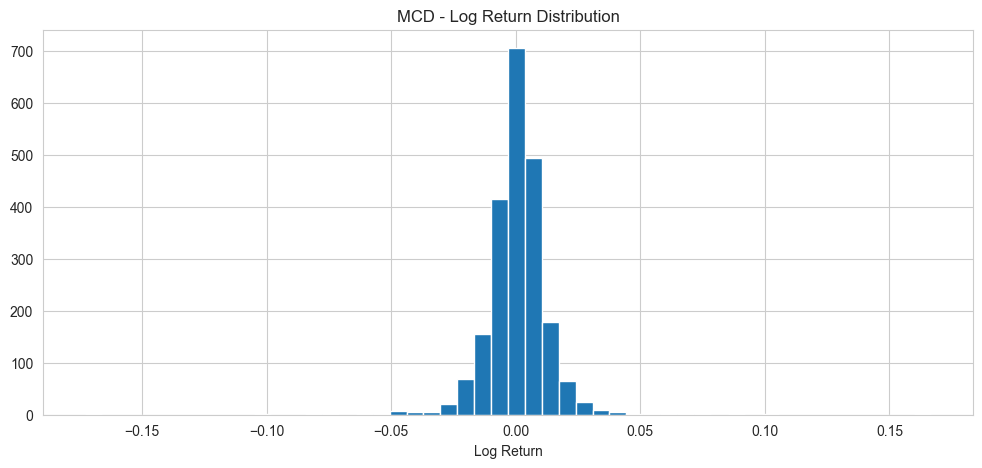

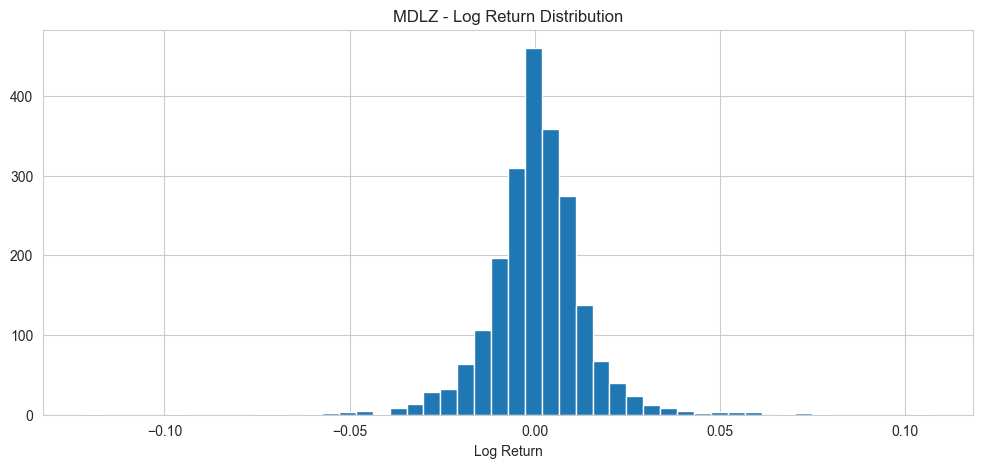

In [23]:
plt.figure()
plt.hist(df["brent_ret"], bins=50)
plt.title("Brent Oil - Log Return Distribution")
plt.xlabel("Log Return")
plt.show()

plt.figure()
plt.hist(df["KO_ret"], bins=50)
plt.title("KO - Log Return Distribution")
plt.xlabel("Log Return")
plt.show()

plt.figure()
plt.hist(df["KHC_ret"], bins=50)
plt.title("KHC - Log Return Distribution")
plt.xlabel("Log Return")
plt.show()

plt.figure()
plt.hist(df["MCD_ret"], bins=50)
plt.title("MCD - Log Return Distribution")
plt.xlabel("Log Return")
plt.show()

plt.figure()
plt.hist(df["MDLZ_ret"], bins=50)
plt.title("MDLZ - Log Return Distribution")
plt.xlabel("Log Return")
plt.show()


### 4.6 Scatter Plots: Oil vs Stocks

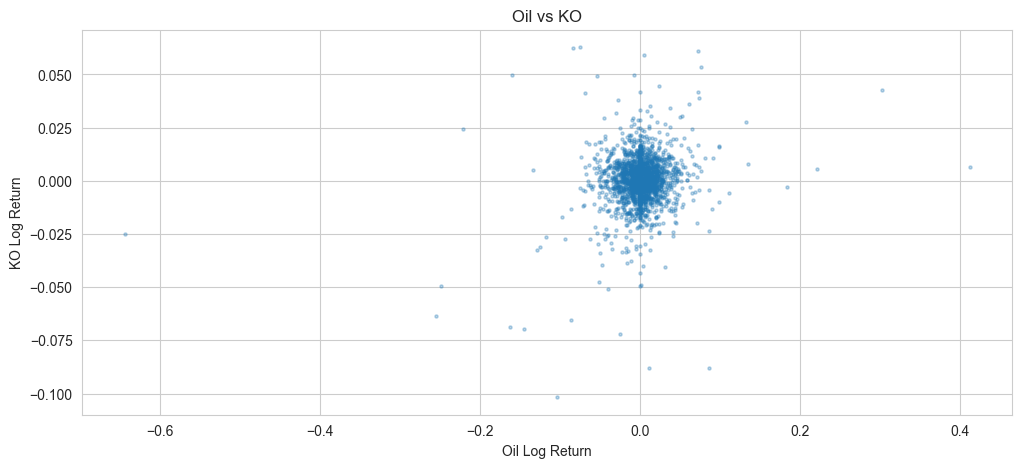

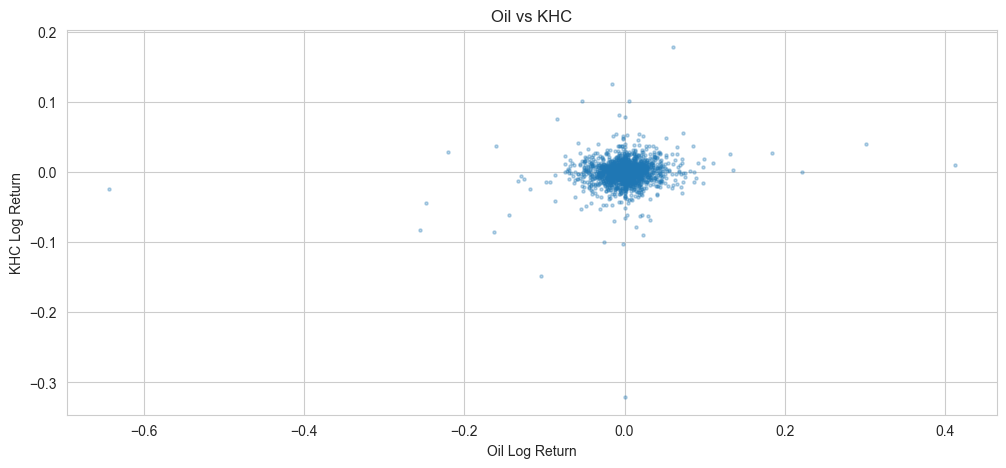

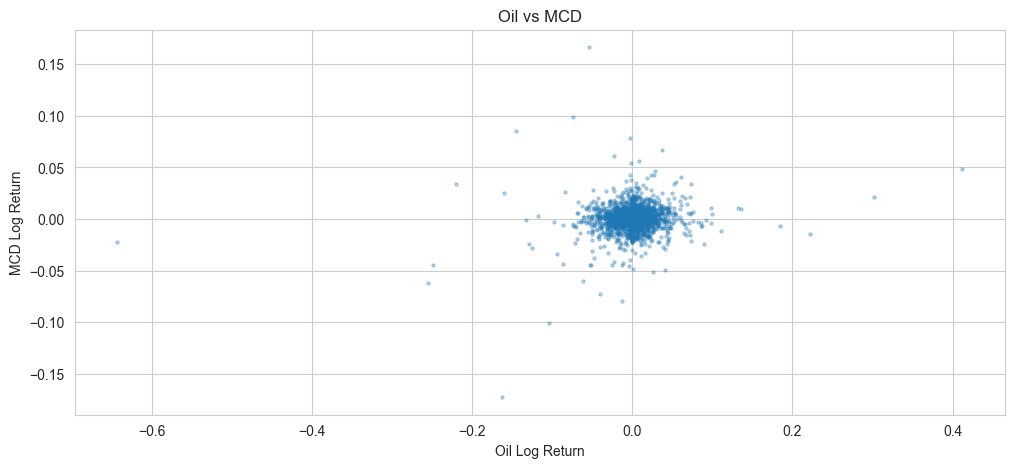

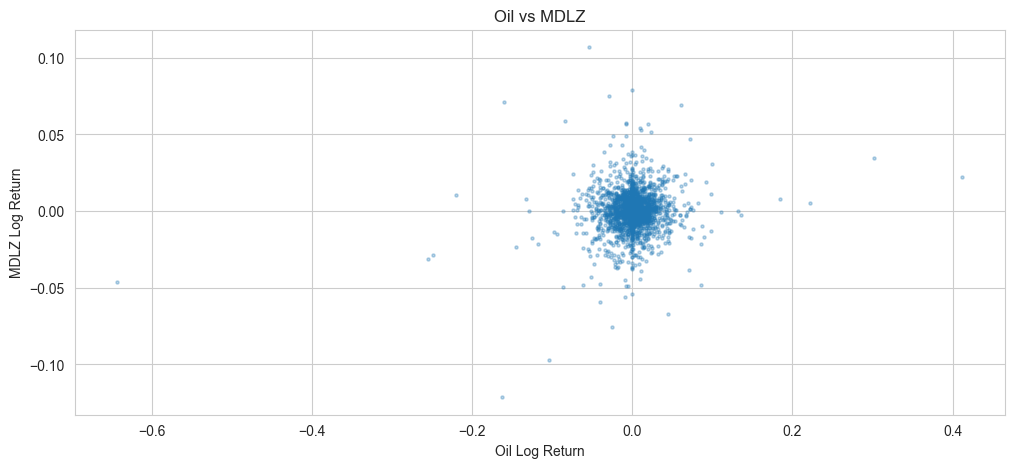

In [24]:
plt.figure()
plt.scatter(df["brent_ret"], df["KO_ret"], alpha=0.3, s=5)
plt.title("Oil vs KO")
plt.xlabel("Oil Log Return")
plt.ylabel("KO Log Return")
plt.show()

plt.figure()
plt.scatter(df["brent_ret"], df["KHC_ret"], alpha=0.3, s=5)
plt.title("Oil vs KHC")
plt.xlabel("Oil Log Return")
plt.ylabel("KHC Log Return")
plt.show()

plt.figure()
plt.scatter(df["brent_ret"], df["MCD_ret"], alpha=0.3, s=5)
plt.title("Oil vs MCD")
plt.xlabel("Oil Log Return")
plt.ylabel("MCD Log Return")
plt.show()

plt.figure()
plt.scatter(df["brent_ret"], df["MDLZ_ret"], alpha=0.3, s=5)
plt.title("Oil vs MDLZ")
plt.xlabel("Oil Log Return")
plt.ylabel("MDLZ Log Return")
plt.show()


### 4.7 Rolling Correlation (90 days)

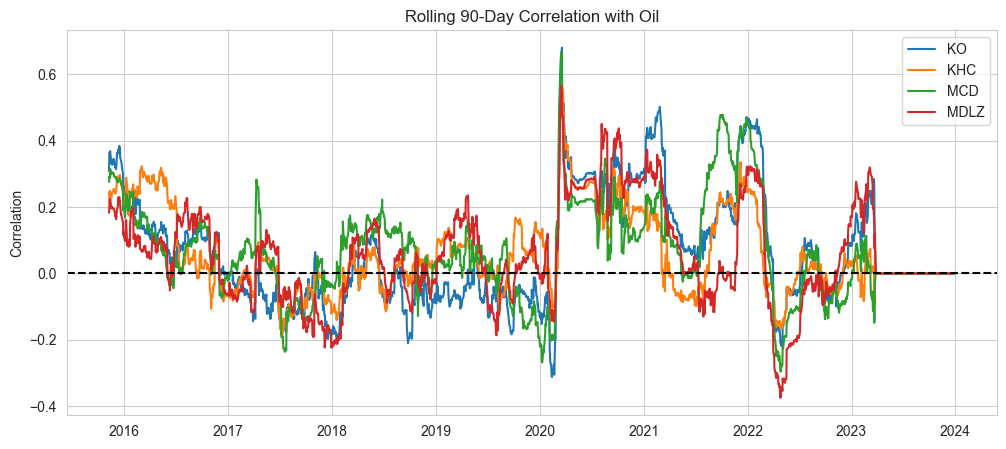

In [25]:
roll_KO   = df["brent_ret"].rolling(90).corr(df["KO_ret"])
roll_KHC  = df["brent_ret"].rolling(90).corr(df["KHC_ret"])
roll_MCD  = df["brent_ret"].rolling(90).corr(df["MCD_ret"])
roll_MDLZ = df["brent_ret"].rolling(90).corr(df["MDLZ_ret"])

plt.figure()
plt.plot(df["date"], roll_KO,   label="KO")
plt.plot(df["date"], roll_KHC,  label="KHC")
plt.plot(df["date"], roll_MCD,  label="MCD")
plt.plot(df["date"], roll_MDLZ, label="MDLZ")
plt.axhline(0, color="black", linestyle="--")
plt.title("Rolling 90-Day Correlation with Oil")
plt.ylabel("Correlation")
plt.legend()
plt.show()
